# SBP 代數性質自動驗證 Notebook

本 Notebook 用於檢查離散算子是否滿足 Summation-By-Parts (SBP) 核心恆等式：

$$W D + D^T W = E^T B E$$

其中：
- $W$：體積積分權重矩陣（Volume Mass Matrix）
- $D$：微分矩陣（Differentiation Matrix）
- $E$：邊界提取/外推矩陣（Boundary Extraction/Extrapolation Matrix）
- $B$：邊界積分權重矩陣（Boundary Mass Matrix）

此 Notebook 會輸出誤差指標、0 階一致性檢查，並以熱力圖視覺化 LHS、RHS 與殘差。

In [1]:
from __future__ import annotations

import sys
from dataclasses import dataclass
from pathlib import Path
from typing import Dict

import matplotlib.pyplot as plt
import numpy as np

PROJECT_ROOT = Path.cwd().resolve()
while PROJECT_ROOT != PROJECT_ROOT.parent and not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.bases.vandermonde import grad_vandermonde_2d_dubiner, vandermonde_2d_dubiner
from src.core.generators import get_reference_data
from src.reconstruction import build_differentiation_matrices
from src.reconstruction.boundary import build_extraction_matrix_E, build_fmask_table1

np.set_printoptions(precision=6, suppress=True)

## 1. 核心驗證函數

定義模組化函數 verify_sbp_property(W, D, E, B, tol=1e-12)，內含：

1. 左側矩陣：Q = WD，LHS = Q + Q^T
2. 右側矩陣：RHS = E^T B E
3. 殘差矩陣：R = LHS - RHS
4. 誤差範數：L∞ norm 與 Frobenius norm
5. 0 階一致性：檢查 D1 = 0

In [2]:
@dataclass
class SBPVerificationResult:
    """Container for SBP algebra verification outputs.

    Stores intermediate matrices and error metrics used to assess whether
    a discrete operator satisfies the SBP identity
    $W D + D^T W = E^T B E$.
    """

    lhs: np.ndarray
    rhs: np.ndarray
    residual: np.ndarray
    linf_residual: float
    fro_residual: float
    linf_consistency: float
    is_sbp: bool
    is_consistent: bool
    passed: bool


def verify_sbp_property(
    W: np.ndarray,
    D: np.ndarray,
    E: np.ndarray,
    B: np.ndarray,
    tol: float = 1e-12,
) -> SBPVerificationResult:
    r"""Verify the discrete SBP identity for a single differentiation operator.

    This function evaluates the algebraic property

    $$W D + D^T W = E^T B E$$

    and computes matrix residual norms together with the 0-th order
    consistency condition

    $$D\mathbf{1} = \mathbf{0}. $$

    In SBP-DG discretizations, this check is a minimal requirement for
    conservation and for preventing artificial source generation from the
    derivative operator.

    Args:
        W: Volume mass matrix of shape (N, N), typically diagonal SPD.
        D: Differentiation matrix of shape (N, N).
        E: Boundary extraction/extrapolation matrix of shape (Nf, N).
        B: Boundary mass/sign matrix of shape (Nf, Nf), typically diagonal.
        tol: Floating-point tolerance for PASS/FAIL decisions.

    Returns:
        SBPVerificationResult containing LHS/RHS/residual matrices, error
        norms, consistency error, and boolean pass flags.

    Example:
        >>> ops = build_reference_sbp_operators(method="table1", k=3)
        >>> result = verify_sbp_property(
        ...     W=ops["W"], D=ops["D_r"], E=ops["E_r"], B=ops["B_r"], tol=1e-12
        ... )
        >>> isinstance(result.passed, bool)
        True
    """
    if W.ndim != 2 or D.ndim != 2 or E.ndim != 2 or B.ndim != 2:
        raise ValueError("W, D, E, B 必須全部為二維矩陣。")

    n = W.shape[0]
    if W.shape != (n, n):
        raise ValueError(f"W 必須為方陣，收到 shape={W.shape}")
    if D.shape != (n, n):
        raise ValueError(f"D 必須與 W 同維度，收到 shape={D.shape}")
    if E.shape[1] != n:
        raise ValueError(f"E 的欄數必須等於 N={n}，收到 shape={E.shape}")
    if B.shape != (E.shape[0], E.shape[0]):
        raise ValueError(
            "B 的 shape 必須為 (Nf, Nf)，且 Nf 等於 E 的列數；"
            f"收到 B={B.shape}, E={E.shape}"
        )

    Q = W @ D
    lhs = Q + Q.T
    rhs = E.T @ B @ E
    residual = lhs - rhs

    linf_residual = float(np.max(np.abs(residual)))
    fro_residual = float(np.linalg.norm(residual, ord="fro"))

    ones = np.ones(n)
    d_one = D @ ones
    linf_consistency = float(np.max(np.abs(d_one)))

    is_sbp = linf_residual <= tol
    is_consistent = linf_consistency <= tol

    return SBPVerificationResult(
        lhs=lhs,
        rhs=rhs,
        residual=residual,
        linf_residual=linf_residual,
        fro_residual=fro_residual,
        linf_consistency=linf_consistency,
        is_sbp=is_sbp,
        is_consistent=is_consistent,
        passed=bool(is_sbp and is_consistent),
    )


def print_sbp_report(result: SBPVerificationResult, tol: float) -> None:
    """Print a compact PASS/FAIL report for SBP verification."""
    verdict = "PASS" if result.passed else "FAIL"
    sbp_flag = "PASS" if result.is_sbp else "FAIL"
    consistency_flag = "PASS" if result.is_consistent else "FAIL"

    print("=" * 72)
    print("SBP Algebra Verification Report")
    print("=" * 72)
    print(f"Tolerance                       : {tol:.2e}")
    print(f"Residual ||R||_inf              : {result.linf_residual:.6e}")
    print(f"Residual ||R||_F                : {result.fro_residual:.6e}")
    print(f"Consistency ||D*1||_inf         : {result.linf_consistency:.6e}")
    print(f"SBP identity check              : {sbp_flag}")
    print(f"0-th order consistency check    : {consistency_flag}")
    print(f"Overall verdict                 : {verdict}")
    print("=" * 72)


def plot_sbp_matrices(
    lhs: np.ndarray,
    rhs: np.ndarray,
    residual: np.ndarray,
    title_prefix: str = "SBP",
) -> None:
    """Visualize LHS, RHS and residual matrices with heatmaps."""
    fig, axes = plt.subplots(1, 3, figsize=(14, 4.2), constrained_layout=True)
    if isinstance(axes, np.ndarray):
        axes_iter = axes.ravel().tolist()
    else:
        axes_iter = [axes]

    matrices = [lhs, rhs, residual]
    titles = [
        f"{title_prefix}: W D + D^T W",
        f"{title_prefix}: E^T B E",
        f"{title_prefix}: Residual R",
    ]

    for ax, mat, title in zip(axes_iter, matrices, titles):
        im = ax.matshow(mat, cmap="coolwarm")
        ax.set_title(title)
        ax.set_xlabel("j")
        ax.set_ylabel("i")
        fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    plt.show()

## 2. 資料載入與正式算子建構（不使用 Dummy Data）

此區塊使用專案既有 API 自動建構 SBP 驗證所需矩陣：

1. 使用 get_reference_data(method, k) 取得節點與體積/邊界權重
2. 使用 vandermonde_2d_dubiner 與 grad_vandermonde_2d_dubiner 建構基底與導數基底
3. 使用 build_differentiation_matrices 建構 D_r, D_s
4. 使用 build_fmask_table1 與 build_extraction_matrix_E 建構邊界提取矩陣 E
5. 根據參考三角形外法向量與邊長，組裝 B_r 與 B_s

對應 2D SBP 關係式：

$$W D_r + D_r^T W = E^T B_r E,$$
$$W D_s + D_s^T W = E^T B_s E.$$

In [3]:
def build_reference_sbp_operators(
    method: str = "table1",
    k: int = 3,
) -> Dict[str, np.ndarray]:
    """Build reference-element SBP operators from project APIs.

    This routine follows the project-standard assembly path:
    get_reference_data -> Vandermonde/gradient Vandermonde ->
    build_differentiation_matrices -> boundary extraction operators.

    For the reference simplex domain (r, s) with vertices (1,0), (0,1), (0,0),
    face ordering from build_fmask_table1 is:
    - face 0: L3 = 0 (r + s = 1)
    - face 1: L1 = 0 (r = 0)
    - face 2: L2 = 0 (s = 0)

    We assemble directional boundary matrices as
    B_r = diag(w_f * n_r), B_s = diag(w_f * n_s),
    where w_f includes edge-Jacobian scaling J_f = |edge|/2.

    Args:
        method: Reference quadrature rule name ('table1' or 'table2').
        k: Polynomial degree.

    Returns:
        Dictionary containing W, D_r, D_s, E, E_r, E_s, B_r, B_s,
        bary_coords, fmask, xi, eta, weights_2d, and weights_1d.

    Example:
        >>> ops = build_reference_sbp_operators(method="table1", k=3)
        >>> ops["W"].shape[0] == ops["D_r"].shape[0]
        True
    """
    ref_data = get_reference_data(method, k)
    xi = ref_data["xi"]
    eta = ref_data["eta"]
    weights_2d = ref_data["weights"]
    weights_1d = ref_data["weights_1d"]
    bary_coords = ref_data["bary_coords"]

    V = vandermonde_2d_dubiner(xi, eta, k)
    V_r, V_s = grad_vandermonde_2d_dubiner(xi, eta, k)
    D_r, D_s = build_differentiation_matrices(V, V_r, V_s, w=weights_2d)
    W = np.diag(weights_2d)

    fmask = build_fmask_table1(bary_coords)
    nfp = fmask.shape[0]
    if len(weights_1d) != nfp:
        raise ValueError(
            f"Boundary weight length mismatch: len(weights_1d)={len(weights_1d)} != nfp={nfp}"
        )

    E_t = build_extraction_matrix_E(fmask, num_volume_nodes=W.shape[0])
    E = E_t.T.astype(float)

    face_lengths = np.array([np.sqrt(2.0), 1.0, 1.0], dtype=float)
    face_jacobians = 0.5 * face_lengths

    normals_r = np.array([1.0 / np.sqrt(2.0), -1.0, 0.0], dtype=float)
    normals_s = np.array([1.0 / np.sqrt(2.0), 0.0, -1.0], dtype=float)

    w_face = np.concatenate([weights_1d * face_jacobians[f] for f in range(3)])
    n_r_face = np.repeat(normals_r, nfp)
    n_s_face = np.repeat(normals_s, nfp)

    B_r = np.diag(w_face * n_r_face)
    B_s = np.diag(w_face * n_s_face)

    return {
        "W": W,
        "D_r": D_r,
        "D_s": D_s,
        "E": E,
        "E_r": E,
        "E_s": E,
        "B_r": B_r,
        "B_s": B_s,
        "bary_coords": bary_coords,
        "fmask": fmask,
        "xi": xi,
        "eta": eta,
        "weights_2d": weights_2d,
        "weights_1d": weights_1d,
    }


# ===== 正式矩陣建構（不使用 Dummy Data） =====
METHOD = "table1"
K = 3

ops = build_reference_sbp_operators(method=METHOD, k=K)
W = ops["W"]
D_r = ops["D_r"]
D_s = ops["D_s"]
E = ops["E"]
E_r = ops["E_r"]
E_s = ops["E_s"]
B_r = ops["B_r"]
B_s = ops["B_s"]

# 單方向展示：沿用變數名 D, B 讓後續單方向驗證 Cell 可直接重用
D = D_r
B = B_r

print(f"Reference data method={METHOD}, k={K}")
print(f"Np (volume nodes) = {W.shape[0]}")
print(f"Nfp (nodes/face) = {ops['fmask'].shape[0]}")
print(f"W shape   = {W.shape}")
print(f"D_r shape = {D_r.shape}, D_s shape = {D_s.shape}")
print(f"E shape   = {E.shape}")
print(f"B_r shape = {B_r.shape}, B_s shape = {B_s.shape}")

Reference data method=table1, k=3
Np (volume nodes) = 18
Nfp (nodes/face) = 4
W shape   = (18, 18)
D_r shape = (18, 18), D_s shape = (18, 18)
E shape   = (12, 18)
B_r shape = (12, 12), B_s shape = (12, 12)


## 3. 執行單方向（r）SBP 驗證與視覺化

本區塊先檢查 r 方向：
1. 執行 SBP 代數性質與 0 階一致性檢查
2. 列印 PASS/FAIL 判定
3. 繪製三個熱力圖：WD + D^T W、E^TBE、殘差 R

SBP Algebra Verification Report
Tolerance                       : 1.00e-12
Residual ||R||_inf              : 5.102611e-01
Residual ||R||_F                : 1.170902e+00
Consistency ||D*1||_inf         : 8.326673e-16
SBP identity check              : FAIL
0-th order consistency check    : PASS
Overall verdict                 : FAIL


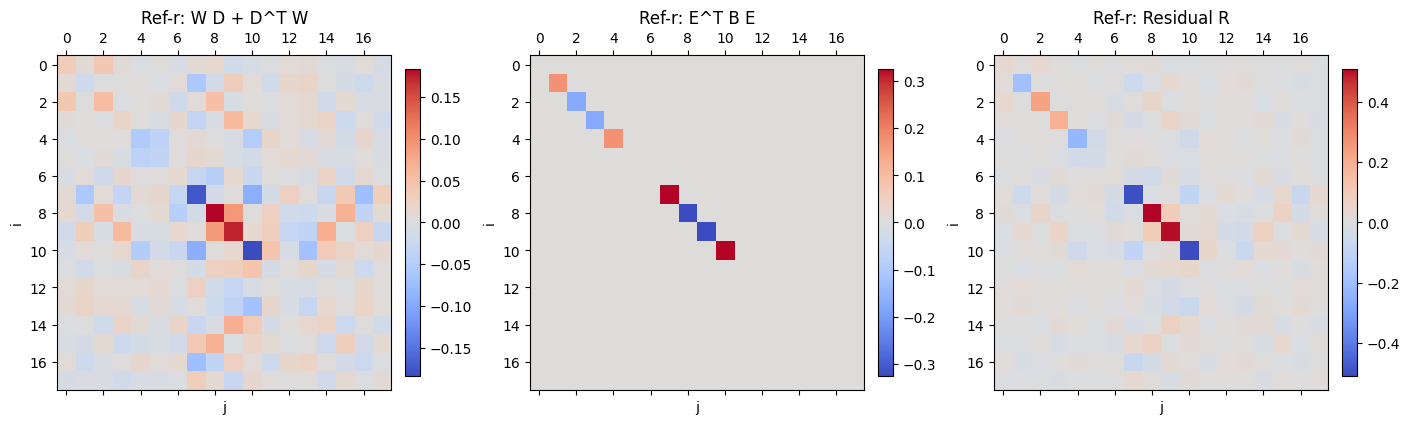

In [4]:
TOL = 1e-12

result = verify_sbp_property(W=W, D=D, E=E, B=B, tol=TOL)
print_sbp_report(result, tol=TOL)
plot_sbp_matrices(result.lhs, result.rhs, result.residual, title_prefix="Ref-r")

## 4. 2D（$D_r$, $D_s$）延伸檢查範例

對於 2D SBP-DG，通常需分方向分別檢查：

$$W D_r + D_r^T W = E_r^T B_r E_r,$$
$$W D_s + D_s^T W = E_s^T B_s E_s.$$

若你已有 `D_r, D_s, E_r, B_r, E_s, B_s`，執行下方 Cell 即可得到雙方向報告。


[Direction r]
SBP Algebra Verification Report
Tolerance                       : 1.00e-12
Residual ||R||_inf              : 5.102611e-01
Residual ||R||_F                : 1.170902e+00
Consistency ||D*1||_inf         : 8.326673e-16
SBP identity check              : FAIL
0-th order consistency check    : PASS
Overall verdict                 : FAIL


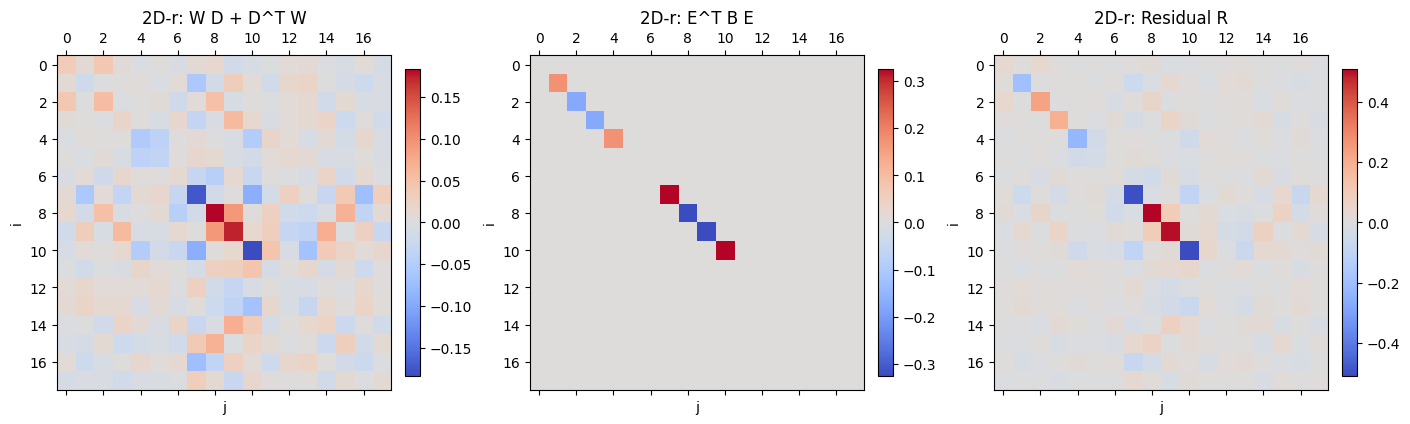


[Direction s]
SBP Algebra Verification Report
Tolerance                       : 1.00e-12
Residual ||R||_inf              : 3.373823e-01
Residual ||R||_F                : 7.723117e-01
Consistency ||D*1||_inf         : 8.881784e-16
SBP identity check              : FAIL
0-th order consistency check    : PASS
Overall verdict                 : FAIL


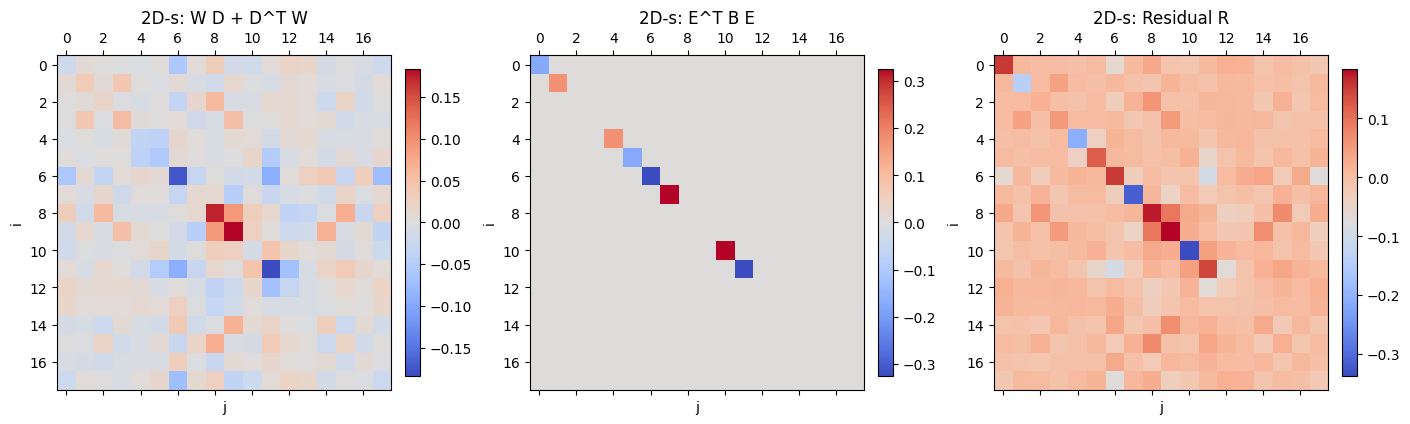

In [5]:
def verify_sbp_2d_directions(
    W: np.ndarray,
    D_r: np.ndarray,
    D_s: np.ndarray,
    E_r: np.ndarray,
    B_r: np.ndarray,
    E_s: np.ndarray,
    B_s: np.ndarray,
    tol: float = 1e-12,
) -> Dict[str, SBPVerificationResult]:
    """Verify SBP properties for both r and s derivative operators."""
    return {
        "r": verify_sbp_property(W, D_r, E_r, B_r, tol=tol),
        "s": verify_sbp_property(W, D_s, E_s, B_s, tol=tol),
    }


RUN_2D_CHECK = True

if RUN_2D_CHECK:
    results_2d = verify_sbp_2d_directions(
        W=W,
        D_r=D_r,
        D_s=D_s,
        E_r=E_r,
        B_r=B_r,
        E_s=E_s,
        B_s=B_s,
        tol=TOL,
    )

    print("\n[Direction r]")
    print_sbp_report(results_2d["r"], tol=TOL)
    plot_sbp_matrices(
        results_2d["r"].lhs,
        results_2d["r"].rhs,
        results_2d["r"].residual,
        title_prefix="2D-r",
    )

    print("\n[Direction s]")
    print_sbp_report(results_2d["s"], tol=TOL)
    plot_sbp_matrices(
        results_2d["s"].lhs,
        results_2d["s"].rhs,
        results_2d["s"].residual,
        title_prefix="2D-s",
    )

In [ ]:
import numpy as np

def verify_skew_symmetric_cancellation(W, D, num_tests=100):
    """
    驗證斜對稱形式 (Skew-Symmetric Form) 的核心代數抵銷性質：
    Test_Residual = (u ⊙ q)^T W (D q) - q^T W (u ⊙ D q) ≈ 0

    參數:
    W: 體積積分權重矩陣 (Diagonal Mass Matrix)
    D: 微分矩陣 (Differentiation Matrix)
    num_tests: 隨機測試次數
    """
    n_nodes = W.shape[0]
    max_residual = 0.0

    for _ in range(num_tests):
        # 1. 隨機生成狀態向量 q 與 隨機場/速度場 u (模擬高度非線性的物理狀態)
        q = np.random.rand(n_nodes)
        u = np.random.rand(n_nodes)

        # 2. 計算空間微分 Dq
        Dq = D @ q

        # 3. 計算 Hadamard product (element-wise multiplication, 符號 ⊙)
        u_q = u * q      # u ⊙ q
        u_Dq = u * Dq    # u ⊙ Dq

        # 4. 計算離散內積 (包含權重矩陣 W)
        term1 = u_q.T @ W @ Dq
        term2 = q.T @ W @ u_Dq

        # 5. 計算這兩項的差值 (殘差)
        residual = np.abs(term1 - term2)
        max_residual = max(max_residual, residual)

    return max_residual

# ===================================================================== #
# 執行測試 (利用你 Notebook 中已經算好的 W, D_r, D_s)
# ===================================================================== #
print("=== 🌟 Skew-Symmetric Formulation Energy Cancellation Test 🌟 ===")
print("驗證指標: (u ⊙ q)^T W (D_xi q)  ==  q^T W (u ⊙ D_xi q)\n")

# 測試 r 方向
res_r = verify_skew_symmetric_cancellation(W, D_r)
print(f"[Direction r] 最大殘差: {res_r:.4e}")
if res_r < 1e-13:
    print("  ✅ 完美通過！r 方向的非線性對流項達到機器精度級別的抵銷。")
else:
    print("  ❌ 未通過，殘差過大。請檢查 W 是否為嚴格的對角線矩陣。")

print("-" * 60)

# 測試 s 方向
res_s = verify_skew_symmetric_cancellation(W, D_s)
print(f"[Direction s] 最大殘差: {res_s:.4e}")
if res_s < 1e-13:
    print("  ✅ 完美通過！s 方向的非線性對流項達到機器精度級別的抵銷。")
else:
    print("  ❌ 未通過，殘差過大。")

=== 🌟 Skew-Symmetric Formulation Energy Cancellation Test 🌟 ===
驗證指標: (u ⊙ q)^T W (D_xi q)  ==  q^T W (u ⊙ D_xi q)

[Direction r] 最大殘差: 2.7756e-17
  ✅ 完美通過！r 方向的非線性對流項達到機器精度級別的抵銷。
------------------------------------------------------------
[Direction s] 最大殘差: 2.7756e-17
  ✅ 完美通過！s 方向的非線性對流項達到機器精度級別的抵銷。
